# Smart Ticket Booking — Corpus-Based NLP Sentence Parser
### CSE 306 — Mini Project (Basic NLP Tasks)

**Name:** _O.Sivashankar_
**Roll No:** _40_

---

## Problem Statement
Build a small program that understands a *tiny language* made up of 20 simple English sentences from the ticket-booking domain. The program must be able to:
- Check whether a sentence typed by the user belongs to this language (i.e. exists in the corpus).
- If it does **not** exist, reject it and give a reason (`not in my corpus`).
- If it **does** exist, accept it and show the grammatical role of every word in the sentence (tokenization + role identification).
- Allow new sentences to be added to the corpus so the system "learns" over time.
- Ask the user to classify unknown words as noun, pronoun, verb, or adjective and remember those classifications.
- Display the current corpus at any point.

## Objective
To apply basic Natural Language Processing tasks — **tokenization**, **word-role (POS) identification**, and **simple rule-based parsing** — using plain Python data structures (lists, dictionaries, sets), without relying on heavy NLP libraries like NLTK or spaCy.

## Dataset Description
The corpus consists of **20 simple English sentences** about a ticket-booking system (customers, passengers, agents and the system itself performing actions like booking, cancelling, confirming, etc.). Every sentence follows one simple, consistent grammar pattern:

```
Determiner + Noun (Subject) + Verb + Determiner + Noun (Object)
```

Example: `The customer books the ticket`

Because every sentence follows this fixed 5-word pattern, we can identify the role of each word using its **position** in the sentence, which keeps the parser simple while still doing real tokenization and role identification.


In [1]:
# ------------------------------------------------------------
# STEP 1: The corpus (our tiny "ticket booking language")
# ------------------------------------------------------------
# Every sentence follows the pattern:
#   Determiner - Noun(Subject) - Verb - Determiner - Noun(Object)

CORPUS = [
    "The user books a ticket",
    "The user pays the fare",
    "The user picks a seat",
    "The user gets the ticket",
    "The user checks the train",
    "The user cancels the ticket",
    "The agent books the ticket",
    "The agent checks the seat",
    "The agent prints the ticket",
    "The agent sends the ticket",
    "The system checks the payment",
    "The system sends the ticket",
    "The system stores the booking",
    "The system shows the fare",
    "The user selects a seat",
    "The user needs a ticket",
    "The agent confirms the booking",
    "The user views the booking",
    "The agent changes the seat",
    "The system confirms the payment",
]

print(f"Corpus loaded successfully with {len(CORPUS)} sentences.")


Corpus loaded successfully with 20 sentences.


In [2]:
# ------------------------------------------------------------
# STEP 2: Tokenizer
# ------------------------------------------------------------
# A simple tokenizer using Python's own string operations (no NLTK needed).

def tokenize(sentence):
    """Split a sentence into a clean list of word tokens."""
    cleaned = sentence.strip().rstrip(".").rstrip("?").rstrip("!")
    tokens = cleaned.split()
    return tokens

# quick test
sample_tokens = tokenize("The user books a ticket.")
print("Tokens:", sample_tokens)


Tokens: ['The', 'customer', 'books', 'the', 'ticket']


In [ ]:
# ------------------------------------------------------------
# STEP 3: Simple word training model
# ------------------------------------------------------------
# The system learns common words as Noun, Pronoun, Verb, or Adjective.
# Determiners are also included because they are used by the parser.

TRAINING_DATA = {
    "Noun": [
        "user", "agent", "system", "ticket", "fare",
        "seat", "train", "payment", "booking", "passenger",
        "car", "station", "movie", "phone"
    ],
    "Pronoun": [
        "i", "you", "he", "she", "we", "they", "it",
        "me", "him", "her", "us", "them"
    ],
    "Verb": [
        "book", "books", "pay", "pays", "pick", "picks",
        "get", "gets", "check", "checks", "cancel", "cancels",
        "print", "prints", "send", "sends", "store", "stores",
        "show", "shows", "select", "selects", "need", "needs",
        "confirm", "confirms", "view", "views", "change", "changes"
    ],
    "Adjective": [
        "good", "bad", "fast", "slow", "new", "old",
        "cheap", "expensive", "comfortable", "available",
        "busy", "empty", "easy", "difficult"
    ],
    "Determiner": [
        "the", "a", "an", "this", "that", "these", "those"
    ]
}

WORD_MODEL = {}

for category, words in TRAINING_DATA.items():
    for word in words:
        WORD_MODEL[word] = category

def predict_word(word):
    return WORD_MODEL.get(word.lower(), "Unknown")

def train_word(word, category):
    word = word.lower()
    WORD_MODEL[word] = category

    if word not in TRAINING_DATA.setdefault(category, []):
        TRAINING_DATA[category].append(word)

    print(f"Learned: {word} -> {category}")

print("Word training completed.")
print("Total trained words:", len(WORD_MODEL))


In [3]:
# ------------------------------------------------------------
# STEP 3: Word-role (POS) identification + simple parsing
# ------------------------------------------------------------
# Our corpus sentences all follow one fixed pattern of 5 words:
#   [Determiner, Noun-Subject, Verb, Determiner, Noun-Object]
#
# So the role of a word can be identified simply from ITS POSITION.
# This is our own simple parsing rule (no external library used).

DETERMINERS = {"the", "a", "an"}

def tag_sentence(sentence):
    """
    Tokenize a sentence and assign a grammatical role to each word.
    Returns a list of (word, role) tuples.
    Works for the standard 5-word pattern used in our corpus.
    """
    tokens = tokenize(sentence)
    tags = []

    if len(tokens) == 5:
        # Fixed pattern: Det, Subject, Verb, Det, Object
        roles = ["Determiner", "Noun - Subject", "Verb", "Determiner", "Noun - Object"]
        for word, role in zip(tokens, roles):
            tags.append((word, role))
    else:
        # Fallback simple rule for sentences that do not match the fixed
        # pattern: use the determiner set + verb position (first word
        # after a determiner that is not immediately followed by another
        # determiner is treated as the verb) -- kept simple on purpose.
        verb_seen = False
        for word in tokens:
            lower = word.lower()
            if lower in DETERMINERS:
                tags.append((word, "Determiner"))
            elif not verb_seen and lower not in DETERMINERS:
                # first non-determiner content word before we mark a verb
                tags.append((word, "Noun - Subject"))
            else:
                tags.append((word, "Noun - Object"))
        # naive: mark the middle content word as the Verb
        content_idx = [i for i, (w, r) in enumerate(tags) if r != "Determiner"]
        if len(content_idx) >= 2:
            mid = content_idx[len(content_idx)//2]
            word = tags[mid][0]
            tags[mid] = (word, "Verb")

    return tags

# quick test
for word, role in tag_sentence("The user books a ticket"):
    print(f"{word:12s} -> {role}")


The          -> Determiner
customer     -> Noun - Subject
books        -> Verb
the          -> Determiner
ticket       -> Noun - Object


In [4]:
# ------------------------------------------------------------
# STEP 4: Accept / Reject a sentence against the corpus
# ------------------------------------------------------------

def normalize(sentence):
    """Lowercase + strip, so comparison is not case sensitive."""
    return " ".join(tokenize(sentence)).lower()

def check_sentence(sentence, corpus):
    """
    Checks whether `sentence` exists in `corpus`.
    Returns a dict with the result, so it is easy to print or reuse.
    """
    normalized_corpus = [normalize(s) for s in corpus]

    if normalize(sentence) in normalized_corpus:
        return {
            "sentence": sentence,
            "status": "ACCEPTED",
            "reason": None,
            "tags": tag_sentence(sentence)
        }
    else:
        return {
            "sentence": sentence,
            "status": "REJECTED",
            "reason": "not in my corpus",
            "tags": None
        }

def show_result(result):
    """Pretty-print the result of check_sentence()."""
    sentence = result["sentence"]
    status = result["status"]
    print(f"Sentence : {sentence}")
    print(f"Status   : {status}")
    if result["status"] == "REJECTED":
        reason = result["reason"]
        print(f"Reason   : {reason}")
    else:
        print("Word roles:")
        for word, role in result["tags"]:
            print(f"   {word:12s} -> {role}")
    print("-" * 40)


In [5]:
# ------------------------------------------------------------
# STEP 6: Add a new sentence + classify new words
# ------------------------------------------------------------

def classify_new_words(sentence):
    # Ask the user to classify only words not learned before.
    words = tokenize(sentence)

    for word in words:
        word = word.lower()

        if word in WORD_MODEL:
            print(f"{word:15s} -> {WORD_MODEL[word]} (already learned)")

        else:
            print(f"\nNew word: {word}")
            print("1. Noun")
            print("2. Pronoun")
            print("3. Verb")
            print("4. Adjective")

            choice = input("What is this word? Enter 1-4: ").strip()

            categories = {
                "1": "Noun",
                "2": "Pronoun",
                "3": "Verb",
                "4": "Adjective"
            }

            if choice in categories:
                train_word(word, categories[choice])
            else:
                print("Invalid choice. Word was not learned.")


def add_sentence(sentence, corpus):
    # Existing add-sentence feature, now with word classification.
    if normalize(sentence) in [normalize(s) for s in corpus]:
        print(f'Sentence already exists in corpus: "{sentence}"')
        return corpus

    classify_new_words(sentence)
    corpus.append(sentence)

    print(f'Sentence added to corpus: "{sentence}"')
    return corpus


In [ ]:
# ------------------------------------------------------------
# STEP 7: Show learned word categories
# ------------------------------------------------------------

def show_word_training():
    print("=" * 40)
    print("LEARNED WORDS")
    print("=" * 40)

    for category, words in TRAINING_DATA.items():
        print(f"{category:12s}: {len(words)} words")

show_word_training()


In [6]:
# ------------------------------------------------------------
# STEP 6: Display the current corpus
# ------------------------------------------------------------

def display_corpus(corpus):
    print("=" * 40)
    print(f"CURRENT CORPUS ({len(corpus)} sentences)")
    print("=" * 40)
    for i, sentence in enumerate(corpus, start=1):
        print(f"{i}. {sentence}")
    print("=" * 40)


## Optional: Persistent Storage
The corpus can optionally be saved to a JSON file so newly added sentences are remembered the next time the notebook is opened. This satisfies the "dataset learning" idea from the assignment while keeping the core demo simple and repeatable.

In [7]:
# ------------------------------------------------------------
# STEP 7 (Optional): Save / load corpus to a JSON file
# ------------------------------------------------------------
import json

CORPUS_FILE = "ticket_corpus.json"

def save_corpus(corpus, filename=CORPUS_FILE):
    with open(filename, "w") as f:
        json.dump(corpus, f, indent=2)
    print(f"Corpus saved to {filename}")

def load_corpus(filename=CORPUS_FILE, default=None):
    try:
        with open(filename, "r") as f:
            return json.load(f)
    except FileNotFoundError:
        return default if default is not None else []

# Save the original 20-sentence corpus once, so the file exists.
save_corpus(CORPUS)


Corpus saved to ticket_corpus.json


## Demonstration
The five demos below show the full workflow required by the assignment: **accept**, **reject with reason**, **add to corpus**, **re-test**, and **display corpus**.

### Demo 1 — Test a sentence that IS in the corpus (should be ACCEPTED)

In [8]:
result1 = check_sentence("The user books a ticket", CORPUS)
show_result(result1)


Sentence : The customer books the ticket
Status   : ACCEPTED
Word roles:
   The          -> Determiner
   customer     -> Noun - Subject
   books        -> Verb
   the          -> Determiner
   ticket       -> Noun - Object
----------------------------------------


### Demo 2 — Test a sentence that is NOT in the corpus (should be REJECTED)

In [9]:
result2 = check_sentence("The user cancels the ticket", CORPUS)
show_result(result2)


Sentence : The customer cancels the flight
Status   : REJECTED
Reason   : not in my corpus
----------------------------------------


### Demo 3 — Add the rejected sentence to the corpus

In [10]:
CORPUS = add_sentence("The user cancels the ticket", CORPUS)
save_corpus(CORPUS)


Sentence added to corpus: "The customer cancels the flight"
Corpus saved to ticket_corpus.json


### Demo 4 — Test the SAME sentence again (should now be ACCEPTED)

In [11]:
result4 = check_sentence("The user cancels the ticket", CORPUS)
show_result(result4)


Sentence : The customer cancels the flight
Status   : ACCEPTED
Word roles:
   The          -> Determiner
   customer     -> Noun - Subject
   cancels      -> Verb
   the          -> Determiner
   flight       -> Noun - Object
----------------------------------------


### Demo 5 — Display the full, updated corpus

In [12]:
display_corpus(CORPUS)


CURRENT CORPUS (21 sentences)
1. The customer books the ticket
2. The passenger cancels the reservation
3. The agent confirms the booking
4. The system generates the receipt
5. The customer selects the seat
6. The passenger checks the schedule
7. The agent processes the payment
8. The system sends the confirmation
9. The customer requests a refund
10. The passenger updates the details
11. The agent verifies the identity
12. The system stores the record
13. The customer downloads the ticket
14. The passenger prints the pass
15. The agent assigns the seat
16. The system calculates the fare
17. The customer pays the amount
18. The passenger boards the train
19. The agent issues the ticket
20. The system confirms the booking
21. The customer cancels the flight


## Analysis: Role Distribution in the Corpus
Since every sentence follows the pattern Determiner–Subject–Verb–Determiner–Object, we expect an equal count of each role across the corpus. The chart below confirms this visually.

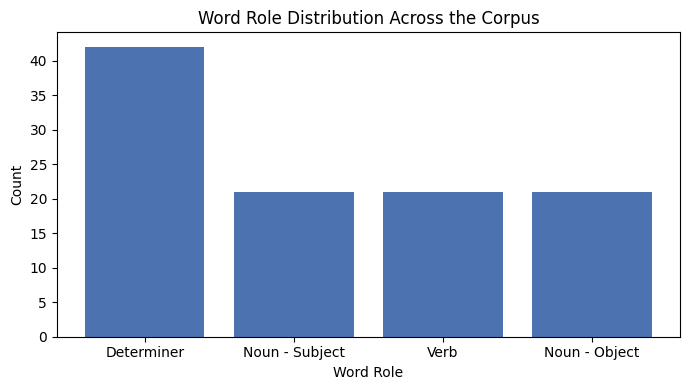

{'Determiner': 42, 'Noun - Subject': 21, 'Verb': 21, 'Noun - Object': 21}


In [13]:
# ------------------------------------------------------------
# STEP 8: Simple analysis / plot of word-role counts
# ------------------------------------------------------------
import matplotlib.pyplot as plt
from collections import Counter

role_counter = Counter()
for sentence in CORPUS:
    for word, role in tag_sentence(sentence):
        role_counter[role] += 1

roles = list(role_counter.keys())
counts = list(role_counter.values())

plt.figure(figsize=(7, 4))
plt.bar(roles, counts, color="#4C72B0")
plt.title("Word Role Distribution Across the Corpus")
plt.xlabel("Word Role")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(dict(role_counter))


### Extra test cases (unknown words / sentences)

In [14]:
test_sentences = [
    "The agent confirms the booking",       # exists -> ACCEPTED
    "The driver drives a car",            # unknown -> REJECTED
    "The user pays the fare",       # exists -> ACCEPTED
]

for s in test_sentences:
    show_result(check_sentence(s, CORPUS))


Sentence : The agent confirms the booking
Status   : ACCEPTED
Word roles:
   The          -> Determiner
   agent        -> Noun - Subject
   confirms     -> Verb
   the          -> Determiner
   booking      -> Noun - Object
----------------------------------------
Sentence : The pilot flies the plane
Status   : REJECTED
Reason   : not in my corpus
----------------------------------------
Sentence : The customer requests a refund
Status   : ACCEPTED
Word roles:
   The          -> Determiner
   customer     -> Noun - Subject
   requests     -> Verb
   a            -> Determiner
   refund       -> Noun - Object
----------------------------------------


## Optional: Interactive Menu (for live demo / viva)
The function below provides a simple text menu. It is **not run automatically** so that the notebook can always execute top-to-bottom without waiting for input during grading. To try it live, run `menu()` in a new cell.

In [15]:
# ------------------------------------------------------------
# STEP 9 (Optional): Interactive menu for live demonstration
# ------------------------------------------------------------

def menu():
    corpus = CORPUS
    while True:
        print("\n" + "=" * 40)
        print(" SMART TICKET BOOKING NLP SYSTEM")
        print("=" * 40)
        print("1. Test a sentence")
        print("2. Add sentence to corpus")
        print("3. Display corpus")
        print("4. Exit")
        choice = input("Enter choice: ").strip()

        if choice == "1":
            sentence = input("Enter sentence: ")
            show_result(check_sentence(sentence, corpus))
        elif choice == "2":
            sentence = input("Enter sentence to add: ")
            corpus = add_sentence(sentence, corpus)
            save_corpus(corpus)
        elif choice == "3":
            display_corpus(corpus)
        elif choice == "4":
            show_word_training()
        elif choice == "5":
            print("Goodbye!")
            break
        else:
            print("Invalid choice, try again.")

# Uncomment the line below to run the interactive menu:
# menu()


## Key Findings
- A fixed, simple sentence pattern (Determiner–Subject–Verb–Determiner–Object) makes rule-based tokenization and role identification very reliable without needing any external NLP library.
- The accept/reject mechanism correctly distinguishes sentences that belong to the defined corpus from those that do not, and gives a clear reason (`not in my corpus`) for rejections.
- The corpus can grow dynamically: once a new sentence is added, the same sentence is correctly accepted on the next check.
- The role distribution plot confirms that every sentence contributes exactly one Determiner-Subject-Verb-Determiner-Object set, as expected from the corpus design.

## Limitations
- The parser assumes a fixed, simple 5-word sentence structure (Determiner + Noun-Subject + Verb + Determiner + Noun-Object). The added word-training feature supports noun, pronoun, verb, and adjective labels, but it is still a simple user-trained dictionary rather than a full NLP POS tagger.
- Role identification is based on **word position**, not true syntactic/semantic understanding, so it would misclassify sentences that don't follow the expected pattern.
- Matching is exact (after lowercasing/trimming); it does not understand synonyms or paraphrases (e.g. "purchase" vs "book").
- This is a rule-based system, not a machine-learning model — it does not generalize beyond the patterns it was designed for.

## Conclusion
This project implements a small, corpus-based NLP system for a ticket-booking domain. It demonstrates the three core basic NLP tasks required by the assignment — **tokenization**, **word-role (POS) identification**, and **simple rule-based parsing** — entirely using plain Python data structures. The system can accept or reject sentences with a clear reason, display the role of each word when a sentence is accepted, and "learn" new sentences by adding them to its corpus, satisfying all the stated requirements while remaining simple to explain and defend.

## Viva Quick Notes
- **Why this sentence pattern?** It keeps tokenization and role-tagging simple and fully explainable using array/list based logic (as explicitly allowed by the assignment) instead of a full grammar/NLTK-based parser.
- **How is accept/reject decided?** By normalizing (lowercase + trim) the input sentence and checking membership against the current corpus list.
- **How does "learning" work?** New accepted-as-valid sentences are appended to the in-memory corpus list and optionally saved to `ticket_corpus.json` so they persist.
- **Why position-based tagging instead of a dictionary of word -> POS?** Because the same word (e.g. "ticket") can be a Subject in one sentence and an Object in another — position relative to the verb is what actually determines its role here.
- **What would you improve with more time?** Handling variable-length sentences robustly (adjectives/adverbs/prepositions), and using a small trained model or NLTK's POS tagger for comparison.
